# Evaluierung des Decoder-Only DPO-Übersetzungsmodells auf dem Lebenshilfe-Datensatz
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook evaluiert das mit **Direct Preference Optimization (DPO)** trainierte **Decoder-Only Sprachmodell** (`Qwen/Qwen2.5-7B-Instruct` mit LoRA und Leichte-Sprache-Systemprompt) auf dem unabhängigen **Lebenshilfe-Testdatensatz**:

1. **DPO- & SFT-Modell laden:** Lädt das Decoder-Only Basismodell (`Qwen/Qwen2.5-7B-Instruct`) und hängt die trainierten LoRA-Adapter aus `results/models/decoder_only/sft` und `results/models/decoder_only/dpo` an.
2. **Reward- & Metrik-Setup:**
   - **Stil & Einfachheit ($R_{\text{style}}$):** BiLSTM Regressor (Mixup).
   - **Semantische Ähnlichkeit ($R_{\text{sem}}$):** Jina SBERT Ähnlichkeit zur AS-Quelle.
   - **Referenz-Treue:** SBERT Ähnlichkeit zur echten menschlichen LS-Referenz.
   - **Composite Reward:** Kombinierter Qualitäts-Score ($R_{\text{total}} = w_{\text{style}} \cdot R_{\text{style}} + w_{\text{sem}} \cdot R_{\text{sem}}$).
3. **Batch-Übersetzung & Evaluierung** auf dem Lebenshilfe-Datensatz unter Verwendung des standardisierten Systemprompts (Regeln W2–W11).
4. **Statistische Gesamtauswertung (DPO):** Deskriptive Kennzahlen & CSV-Export.
5. **Direkter Vergleich: DPO vs. SFT:** Vergleichstabellen, Differenzen, prozentuale Änderungen und Signifikanzprüfungen.
6. **Qualitatives Stichproben-Audit:** 1-zu-1 Gegenüberstellung von AS, Referenz und Modellübersetzungen.
7. **Visualisierung der Metrik-Verteilungen:** Boxplots, KDEs, Histogramme und Publikations-Plots.
8. **Interaktiver Übersetzungstest:** Live-Vereinfachung eigener Texte mit Sofortbewertung.

In [1]:
import os
import sys
import json
import glob
import random
import re
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import torch
import torch.nn as nn
import spacy
import textstat
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from sentence_transformers import SentenceTransformer, util

# Arbeitsverzeichnis auf Projekt-Root setzen
while not os.path.exists(".git"):
    parent = os.path.dirname(os.getcwd())
    if parent == os.getcwd():
        break
    os.chdir("..")

print("Arbeitsverzeichnis:", os.getcwd())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Nutze Device: {DEVICE}")

Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda


In [2]:
# ==============================================================================
# ZENTRALE KONFIGURATION & PFADE
# ==============================================================================
BASE_MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
SFT_MODEL_PATH = "results/models/decoder_only/sft"
DPO_MODEL_PATH = "results/models/decoder_only/dpo"
LH_DATASET_PATH = "data/lebenshilfe/lebenshilfe_dataset_clean.json"

# Reward-Modell & Vokabular (1000-Token-Metrik)
REWARD_MODEL_PATH = "results/models/token_length_exp/bilstm_mixup_regression_1000.pt"
REWARD_VOCAB_PATH = "data/token_length_exp/mixup_vocab_1000.json"

# Fallbacks falls 1000er Pfade nicht existieren
if not os.path.exists(REWARD_MODEL_PATH):
    REWARD_MODEL_PATH = "results/models/bilstm_mixup_regression.pt"
if not os.path.exists(REWARD_VOCAB_PATH):
    REWARD_VOCAB_PATH = "data/vocabs/mixup_vocab.json"

SBERT_MODEL_NAME = "jinaai/jina-embeddings-v2-base-de"
if not os.path.exists(REWARD_MODEL_PATH):
    SBERT_MODEL_NAME = "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"

W_STYLE = 0.7
W_SEM = 0.3
MAX_SOURCE_LEN = 1000
MAX_TARGET_LEN = 1000

print(f"Base Model:            {BASE_MODEL_NAME}")
print(f"SFT Modell-Pfad:       {SFT_MODEL_PATH}")
print(f"DPO Modell-Pfad:       {DPO_MODEL_PATH}")
print(f"Lebenshilfe-Datensatz: {LH_DATASET_PATH}")
print(f"Reward Modell:         {REWARD_MODEL_PATH}")
print(f"Reward Vokabular:      {REWARD_VOCAB_PATH}")
print(f"SBERT Modell:          {SBERT_MODEL_NAME}")

Base Model:            Qwen/Qwen2.5-7B-Instruct
SFT Modell-Pfad:       results/models/decoder_only/sft
DPO Modell-Pfad:       results/models/decoder_only/dpo
Lebenshilfe-Datensatz: data/lebenshilfe/lebenshilfe_dataset_clean.json
Reward Modell:         results/models/bilstm_mixup_regression.pt
Reward Vokabular:      data/vocabs/mixup_vocab.json
SBERT Modell:          jinaai/jina-embeddings-v2-base-de


## 1. DPO- & SFT-Modell sowie Tokenizer laden (Decoder-Only)

In [3]:
SYSTEM_PROMPT_LEICHTE_SPRACHE = """Du bist ein professioneller Übersetzer für deutsche Leichte Sprache. Deine einzige Aufgabe ist es, schwere deutsche Texte in verständliche Leichte Sprache nach den offiziellen Regeln zu übertragen.

WICHTIGE GRUNDREGELN ZUR INHALTSTREUE:
- W1 (Strikte Inhaltstreue): Übersetze NUR die Informationen, die tatsächlich im Ausgangstext stehen.
- KEINE ERFINDUNGEN: Erfinde unter keinen Umständen neue Angebote, Vereine, Broschüren, Orte, E-Mail-Adressen, Telefonnummern, Websites oder Kontaktboxen.
- Behalte alle Namen, Zahlen, Fakten und Daten aus dem Ausgangstext unverändert bei.
- Füge keine erfundenen Einstiegsfragen hinzu, wenn der Ausgangstext keine Fragen stellt.

REGELN DER LEICHTEN SPRACHE:
- W2 (Einfache Wörter): Benutze einfache und genaue Wörter. Vermeide schwere Fachbegriffe und Fremdwörter.
- W5 (Kurze Wörter): Benutze kurze, bekannte Wörter statt langer oder alter Begriffe.
- W6 (Keine Abkürzungen): Schreibe alle Wörter immer vollständig aus (z. B. "das heißt" statt "d. h.").
- W7 (Verbalstil): Verwende Verben (Tu-Wörter) und vermeide Hauptwort-Stil (Nominalstil).
- W8 (Aktiv): Schreibe im Aktiv. Benenne klar handelnde Personen und vermeide Passiv-Formen.
- W9 (Kein Genitiv): Vermeide den 2. Fall (Genitiv). Nutze stattdessen den 3. Fall (Dativ) mit "von" (z. B. "das Haus vom Lehrer").
- W10 (Kein Konjunktiv): Verwende keinen Konjunktiv. Nutze klare Aussagen oder Hilfswörter wie "vielleicht".
- W11 (Positiv formulieren): Formuliere Aussagen positiv und vermeide unnötige Verneinungen.

Erstelle ausschließlich die vereinfachte Übersetzung des Textes ohne zusätzliche Kommentare oder erfundene Inhalte."""

USER_INSTRUCTION_PREFIX = "Vereinfache folgenden Text in verständliche deutsche Leichte Sprache:\n\n"

def create_chat_messages(as_text, ls_text=None):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT_LEICHTE_SPRACHE},
        {"role": "user", "content": f"{USER_INSTRUCTION_PREFIX}{as_text.strip()}"},
    ]
    if ls_text is not None:
        messages.append({"role": "assistant", "content": ls_text.strip()})
    return messages

print("Lade Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # Wichtig für saubere Autoregressive Batch-Generierung

torch_dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else (torch.float16 if torch.cuda.is_available() else torch.float32)

print(f"Lade Basis-Architektur: {BASE_MODEL_NAME} ({torch_dtype})...")
raw_base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    torch_dtype=torch_dtype,
    trust_remote_code=True,
    device_map="auto" if torch.cuda.is_available() else None,
)

# 1. SFT Adapter laden
print("--- 1. SFT-Modell laden ---")
if os.path.exists(os.path.join(SFT_MODEL_PATH, "adapter_config.json")):
    print(f"Lade SFT LoRA-Adapter aus: {SFT_MODEL_PATH}...")
    sft_model = PeftModel.from_pretrained(raw_base_model, SFT_MODEL_PATH)
    sft_model.eval()
    print("SFT LoRA-Adapter erfolgreich geladen!")
else:
    print(f"SFT-Pfad {SFT_MODEL_PATH} nicht gefunden. Verwende Basismodell.")
    sft_model = raw_base_model

# 2. DPO Adapter laden
print("--- 2. DPO-Modell laden ---")
if os.path.exists(os.path.join(DPO_MODEL_PATH, "adapter_config.json")):
    print(f"Lade DPO LoRA-Adapter aus: {DPO_MODEL_PATH}...")
    dpo_model = PeftModel.from_pretrained(raw_base_model, DPO_MODEL_PATH)
    dpo_model.eval()
    print("DPO LoRA-Adapter erfolgreich geladen!")
else:
    print(f"DPO-Pfad {DPO_MODEL_PATH} nicht gefunden. Nutze SFT-Modell als Fallback.")
    dpo_model = sft_model

print("Modell-Initialisierung vollständig abgeschlossen!")

Lade Tokenizer...


`torch_dtype` is deprecated! Use `dtype` instead!


Lade Basis-Architektur: Qwen/Qwen2.5-7B-Instruct (torch.bfloat16)...


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

--- 1. SFT-Modell laden ---
Lade SFT LoRA-Adapter aus: results/models/decoder_only/sft...
SFT LoRA-Adapter erfolgreich geladen!
--- 2. DPO-Modell laden ---
Lade DPO LoRA-Adapter aus: results/models/decoder_only/dpo...


/home/fiete/master-thesis/.venv/lib/python3.12/site-packages/peft/tuners/tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


DPO LoRA-Adapter erfolgreich geladen!
Modell-Initialisierung vollständig abgeschlossen!


## 2. Reward-Evaluator & SBERT Setup

In [4]:
# 1. BiLSTM Regressor
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

# Vokabular & BiLSTM laden
if os.path.exists(REWARD_VOCAB_PATH):
    with open(REWARD_VOCAB_PATH, "r", encoding="utf-8") as f:
        vocab_data = json.load(f)
        reward_stoi = vocab_data.get("stoi", vocab_data)
    unk_idx = reward_stoi.get("<unk>") or reward_stoi.get("<UNK>") or 1
    bilstm_model = BiLSTMRegressor(len(reward_stoi), embed_dim=128, hidden_dim=128)
    if os.path.exists(REWARD_MODEL_PATH):
        raw_state = torch.load(REWARD_MODEL_PATH, map_location="cpu")
        if isinstance(raw_state, dict):
            raw_state = raw_state.get("model_state_dict", raw_state.get("state_dict", raw_state))
        bilstm_model.load_state_dict(raw_state)
        bilstm_model.eval()
        print(f"BiLSTM Regressor erfolgreich geladen von: {REWARD_MODEL_PATH}")
else:
    print(f"Warnung: Reward Modell oder Vokabular nicht gefunden.")
    bilstm_model = None
    reward_stoi = {}
    unk_idx = 1

# SpaCy Tokenizer
try:
    nlp = spacy.load("de_core_news_sm")
except Exception:
    nlp = spacy.blank("de")
    nlp.add_pipe("sentencizer")

def predict_simplicity_score(texts):
    if bilstm_model is None:
        return np.full(len(texts), 0.5)
    scores = []
    for text in texts:
        doc = nlp(str(text or ""))
        tokens = [t.text.lower() for t in doc if not t.is_space]
        indices = [reward_stoi.get(t, unk_idx) for t in tokens[:MAX_TARGET_LEN]]
        if len(indices) == 0:
            indices = [0]
        inp_tensor = torch.tensor([indices], dtype=torch.long, device="cpu")
        with torch.no_grad():
            score = bilstm_model(inp_tensor).item()
        scores.append(score)
    return np.array(scores)

# SBERT Modell
print(f"Lade SBERT Modell: {SBERT_MODEL_NAME}...")
sbert_model = SentenceTransformer(SBERT_MODEL_NAME, trust_remote_code=True, device=str(DEVICE))
if "jina" in SBERT_MODEL_NAME.lower():
    sbert_model.max_seq_length = min(MAX_TARGET_LEN, 1024)
    print(f"Set Jina SBERT max_seq_length to {sbert_model.max_seq_length}")

def predict_semantic_similarity(source_texts, generated_texts):
    with torch.inference_mode():
        emb_src = sbert_model.encode(source_texts, batch_size=8, convert_to_tensor=True, show_progress_bar=False)
        emb_gen = sbert_model.encode(generated_texts, batch_size=8, convert_to_tensor=True, show_progress_bar=False)
        cosine_sims = util.cos_sim(emb_src, emb_gen).diagonal().cpu().numpy()
    return cosine_sims

class CompositeRewardEvaluator:
    def __init__(self, w_style=W_STYLE, w_sem=W_SEM):
        self.w_style = w_style
        self.w_sem = w_sem
        
    def compute_reward(self, source_texts, generated_texts):
        r_style = predict_simplicity_score(generated_texts)
        r_sem = predict_semantic_similarity(source_texts, generated_texts)
        r_sem_norm = np.clip((r_sem + 1.0) / 2.0, 0.0, 1.0)
        total_reward = self.w_style * r_style + self.w_sem * r_sem_norm
        return total_reward, r_style, r_sem_norm

reward_evaluator = CompositeRewardEvaluator(w_style=W_STYLE, w_sem=W_SEM)
print("Reward Evaluator erfolgreich initialisiert!")

BiLSTM Regressor erfolgreich geladen von: results/models/bilstm_mixup_regression.pt
Lade SBERT Modell: jinaai/jina-embeddings-v2-base-de...
Set Jina SBERT max_seq_length to 1000
Reward Evaluator erfolgreich initialisiert!


## 3. Lebenshilfe-Datensatz laden & DPO-Übersetzungen generieren

In [5]:
with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)

print(f"Lebenshilfe Datensatz geladen: {len(lh_data)} Artikel-Paare.")

def generate_decoder_only_batch(model, tokenizer, texts, batch_size=4, max_new_tokens=512, temperature=0.2):
    model.eval()
    tokenizer.padding_side = "left"  # Links-Padding für exaktes Slicing des Prompt-Endes
    all_generated = []
    for i in range(0, len(texts), batch_size):
        batch_src = texts[i : i + batch_size]
        formatted_prompts = []
        for t in batch_src:
            msgs = create_chat_messages(as_text=t, ls_text=None)
            p_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
            formatted_prompts.append(p_str)
            
        inputs = tokenizer(formatted_prompts, padding=True, truncation=True, max_length=MAX_SOURCE_LEN, return_tensors="pt").to(DEVICE)
        input_len = inputs["input_ids"].shape[1]
        with torch.no_grad():
            outputs = model.generate(
                input_ids=inputs["input_ids"],
                attention_mask=inputs.get("attention_mask"),
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                do_sample=False if temperature == 0.0 else True,
                repetition_penalty=1.2,
                no_repeat_ngram_size=3,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
        decoded = tokenizer.batch_decode(outputs[:, input_len:], skip_special_tokens=True)
        all_generated.extend([d.strip() for d in decoded])
    return all_generated

def evaluate_dpo_on_lebenshilfe(model, tokenizer, lh_data, evaluator, batch_size=4):
    as_texts = [str(item.get("as_text") or "").strip() for item in lh_data]
    ls_ref_texts = [str(item.get("ls_text") or "").strip() for item in lh_data]
    
    print(f"Generiere DPO-Übersetzungen für {len(as_texts)} Artikel...")
    gen_texts = generate_decoder_only_batch(model, tokenizer, as_texts, batch_size=batch_size)
    
    print("Berechne Reward- und Ähnlichkeitsmetriken...")
    tot_reward, r_style, r_sem_norm = evaluator.compute_reward(as_texts, gen_texts)
    sim_to_ref = predict_semantic_similarity(ls_ref_texts, gen_texts)
    sim_to_ref_norm = np.clip((sim_to_ref + 1.0) / 2.0, 0.0, 1.0)
    
    df_res = pd.DataFrame({
        "as_text": as_texts,
        "ls_reference": ls_ref_texts,
        "dpo_translation": gen_texts,
        "simplicity_score": r_style,
        "sbert_sim_to_as": r_sem_norm,
        "sbert_sim_to_ref": sim_to_ref_norm,
        "composite_reward": tot_reward,
        "as_char_len": [len(t) for t in as_texts],
        "gen_char_len": [len(t) for t in gen_texts]
    })
    return df_res

dpo_eval_df = evaluate_dpo_on_lebenshilfe(dpo_model, tokenizer, lh_data, reward_evaluator)

Lebenshilfe Datensatz geladen: 37 Artikel-Paare.
Generiere DPO-Übersetzungen für 37 Artikel...
Berechne Reward- und Ähnlichkeitsmetriken...


## 4. Statistische Gesamtauswertung (DPO)

In [6]:
print("\n=================== DPO EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================")
print(f"Ø Simplicity-Score (R_style):       {dpo_eval_df['simplicity_score'].mean():.4f} ± {dpo_eval_df['simplicity_score'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zur AS-Quelle:  {dpo_eval_df['sbert_sim_to_as'].mean():.4f} ± {dpo_eval_df['sbert_sim_to_as'].std():.4f}")
print(f"Ø SBERT-Ähnlichkeit zu LS-Referenz: {dpo_eval_df['sbert_sim_to_ref'].mean():.4f} ± {dpo_eval_df['sbert_sim_to_ref'].std():.4f}")
print(f"Ø Composite Reward:                 {dpo_eval_df['composite_reward'].mean():.4f} ± {dpo_eval_df['composite_reward'].std():.4f}")
print("=================================================================================\n")

# Statistische Kennzahlen anzeigen
metrics_cols = ["simplicity_score", "sbert_sim_to_as", "sbert_sim_to_ref", "composite_reward"]
display(dpo_eval_df[metrics_cols].describe())

# CSV-Export der Ergebnisse
os.makedirs("results", exist_ok=True)
csv_out_path = "results/dpo_decoder_only_lebenshilfe_evaluation.csv"
dpo_eval_df.to_csv(csv_out_path, index=False, encoding="utf-8")
print(f"Detaillierte Evaluierungsergebnisse gespeichert unter: {csv_out_path}")


=================== DPO EVALUIERUNGSERGEBNISSE (LEBENSHILFE) ===================
Ø Simplicity-Score (R_style):       0.5954 ± 0.2633
Ø SBERT-Ähnlichkeit zur AS-Quelle:  0.8165 ± 0.0679
Ø SBERT-Ähnlichkeit zu LS-Referenz: 0.8127 ± 0.0748
Ø Composite Reward:                 0.6617 ± 0.1929



,simplicity_score,sbert_sim_to_as,sbert_sim_to_ref,composite_reward
count,37.000000,37.000000,37.000000,37.000000
mean,0.595401,0.816534,0.812735,0.661741
std,0.263280,0.067925,0.074791,0.192940
min,0.078603,0.662375,0.642591,0.300234
25%,0.452912,0.774548,0.777929,0.564426
50%,0.670305,0.823755,0.839626,0.739041
75%,0.802282,0.863932,0.873289,0.810571
max,0.919100,0.939448,0.938768,0.901903


Detaillierte Evaluierungsergebnisse gespeichert unter: results/dpo_decoder_only_lebenshilfe_evaluation.csv


## 5. Vergleich DPO vs. SFT (sofern SFT-Ergebnisse vorliegen)

In [7]:
# Optional SFT auf Lebenshilfe generieren oder aus CSV laden
sft_csv = "results/sft_decoder_only_lebenshilfe_evaluation.csv"

if not os.path.exists(sft_csv):
    print("Generiere SFT-Vergleichsdaten auf dem Lebenshilfe-Set...")
    as_texts = [str(item.get("as_text") or "").strip() for item in lh_data]
    ls_ref_texts = [str(item.get("ls_text") or "").strip() for item in lh_data]
    sft_gen_texts = generate_decoder_only_batch(sft_model, tokenizer, as_texts, batch_size=4)
    tot_r, r_st, r_se = reward_evaluator.compute_reward(as_texts, sft_gen_texts)
    sim_ref = predict_semantic_similarity(ls_ref_texts, sft_gen_texts)
    sim_ref_norm = np.clip((sim_ref + 1.0) / 2.0, 0.0, 1.0)
    
    sft_df = pd.DataFrame({
        "as_text": as_texts,
        "ls_reference": ls_ref_texts,
        "sft_translation": sft_gen_texts,
        "simplicity_score": r_st,
        "sbert_sim_to_as": r_se,
        "sbert_sim_to_ref": sim_ref_norm,
        "composite_reward": tot_r,
    })
    sft_df.to_csv(sft_csv, index=False, encoding="utf-8")
else:
    print(f"Lade existierende SFT-Evaluierung aus {sft_csv}...")
    sft_df = pd.read_csv(sft_csv)

# Vergleichstabelle erstellen
comparison_data = []
for col in metrics_cols:
    sft_mean = sft_df[col].mean()
    dpo_mean = dpo_eval_df[col].mean()
    diff = dpo_mean - sft_mean
    rel_diff = (diff / sft_mean) * 100 if sft_mean != 0 else 0.0
    
    # Gepaarter t-Test
    t_stat, p_val = stats.ttest_rel(sft_df[col], dpo_eval_df[col])
    sig = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "n.s."))
    
    comparison_data.append({
        "Metrik": col,
        "SFT (Mittelwert)": f"{sft_mean:.4f}",
        "DPO (Mittelwert)": f"{dpo_mean:.4f}",
        "Differenz (Δ)": f"{diff:+.4f}",
        "Relative Änderung": f"{rel_diff:+.2f} %",
        "p-Wert": f"{p_val:.4e}",
        "Signifikanz": sig
    })

comp_df = pd.DataFrame(comparison_data)
print("\n--- DIREKTER VERGLEICH: SFT vs. DPO (LEBENSHILFE TESTSET, DECODER-ONLY) ---")
display(comp_df)

Lade existierende SFT-Evaluierung aus results/sft_decoder_only_lebenshilfe_evaluation.csv...

--- DIREKTER VERGLEICH: SFT vs. DPO (LEBENSHILFE TESTSET, DECODER-ONLY) ---


,Metrik,SFT (Mittelwert),DPO (Mittelwert),Differenz (Δ),Relative Änderung,p-Wert,Signifikanz
0,simplicity_score,0.5630,0.5954,+0.0324,+5.75 %,5.0121e-01,n.s.
1,sbert_sim_to_as,0.8267,0.8165,-0.0102,-1.23 %,2.8320e-01,n.s.
2,sbert_sim_to_ref,0.8161,0.8127,-0.0033,-0.41 %,7.4639e-01,n.s.
3,composite_reward,0.6421,0.6617,+0.0196,+3.06 %,5.7196e-01,n.s.


## 6. Qualitative Stichproben-Analyse

In [8]:
print("--- QUALITATIVE STICHPROBEN (DPO DECODER-ONLY MODELL AUF LEBENSHILFE) ---")
for idx, row in dpo_eval_df.head(5).iterrows():
    print(f"\n[Artikel {idx + 1}]")
    print(f"AS-Quelle:        {row['as_text'][:150]}...")
    print(f"LS-Referenz:      {row['ls_reference'][:150]}...")
    print(f"DPO-Übersetzung:  {row['dpo_translation'][:250]}...")
    print(f"Scores: Style={row['simplicity_score']:.3f} | Sim(AS)={row['sbert_sim_to_as']:.3f} | Sim(Ref)={row['sbert_sim_to_ref']:.3f} | Total={row['composite_reward']:.3f}")

--- QUALITATIVE STICHPROBEN (DPO DECODER-ONLY MODELL AUF LEBENSHILFE) ---

[Artikel 1]
AS-Quelle:        Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werk...
LS-Referenz:      Positionspapier: Bildung und Teilhabe am Arbeitsleben für Alle in einem inklusiven Arbeitsmarkt. Positionspapier bedeutet: Mehrere Gruppen haben diese...
DPO-Übersetzung:  igkeiten kümmern müssen. Und dann gibt es noch die Frage: Wie soll man einen Lebensunterhalt verdienen? Wenn man an einem Tag nur 4 Stunden gearbeitet hat? Oder gar weniger? Dabei ist die Tatsache, dass die meisten Menschen mit Behinderung trotzdem a...
Scores: Style=0.821 | Sim(AS)=0.768 | Sim(Ref)=0.769 | Total=0.805

[Artikel 2]
AS-Quelle:        „Kieler Sicherheitskonzept Sexualstraftäter“ (KSKS) Was ist KSKS? In Schleswig-Holstein ist seit dem 1. Oktober 2008 die Gemeinsame AV des Justiz-, In...
LS-Referenz:      Infos zum Kieler Sicherheit

## 7. Visualisierung der Metrik-Verteilungen

Plot gespeichert unter: results/plots/dpo_decoder_only_lebenshilfe_metrics.png


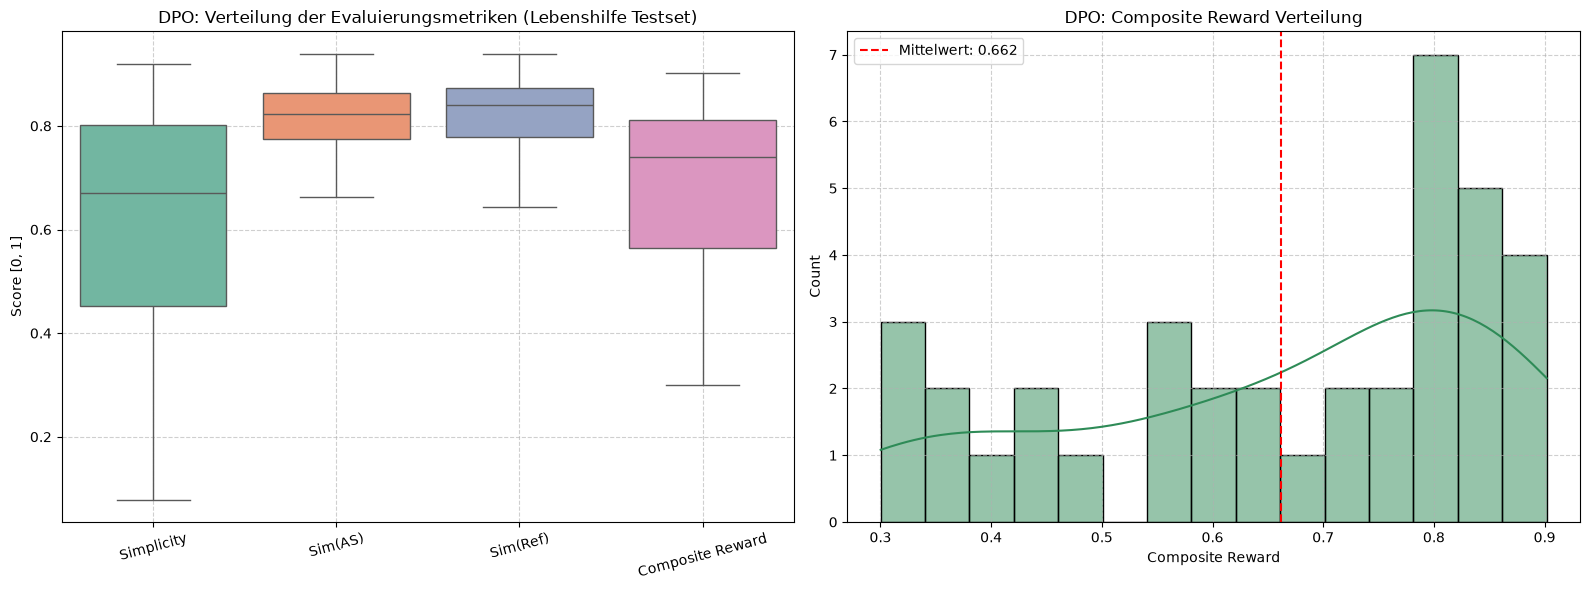

In [9]:
os.makedirs("results/plots", exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Boxplot der Metriken
sns.boxplot(data=dpo_eval_df[metrics_cols], ax=axes[0], palette="Set2")
axes[0].set_title("DPO: Verteilung der Evaluierungsmetriken (Lebenshilfe Testset)", fontsize=12)
axes[0].set_ylabel("Score [0, 1]")
axes[0].set_xticks(range(len(metrics_cols)))
axes[0].set_xticklabels(["Simplicity", "Sim(AS)", "Sim(Ref)", "Composite Reward"], rotation=15)
axes[0].grid(True, linestyle="--", alpha=0.6)

# 2. KDE / Histogramm des Composite Rewards
sns.histplot(dpo_eval_df["composite_reward"], kde=True, ax=axes[1], color="seagreen", bins=15)
axes[1].axvline(dpo_eval_df["composite_reward"].mean(), color="red", linestyle="--", label=f"Mittelwert: {dpo_eval_df['composite_reward'].mean():.3f}")
axes[1].set_title("DPO: Composite Reward Verteilung", fontsize=12)
axes[1].set_xlabel("Composite Reward")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plot_out_path = "results/plots/dpo_decoder_only_lebenshilfe_metrics.png"
plt.savefig(plot_out_path, dpi=300)
print(f"Plot gespeichert unter: {plot_out_path}")
plt.show()

## 8. Interaktiver Übersetzungstest

In [10]:
def translate_dpo_text(text, model=dpo_model, temperature=0.2):
    tokenizer.padding_side = "left"
    msgs = create_chat_messages(as_text=text, ls_text=None)
    prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt_str, return_tensors="pt").to(DEVICE)
    input_len = inputs["input_ids"].shape[1]
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=512,
            temperature=temperature,
            do_sample=False if temperature == 0.0 else True,
                repetition_penalty=1.2,
                no_repeat_ngram_size=3,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    translation = tokenizer.decode(generated_ids[0][input_len:], skip_special_tokens=True).strip()
    
    tot_reward, r_style, r_sem_norm = reward_evaluator.compute_reward([text], [translation])
    
    print("[Eingabe (AS)]:")
    print(text)
    print("")
    print("[DPO-Übersetzung (LS)]:")
    print(translation)
    print("")
    print(f"[Scores]: Simplicity={r_style[0]:.3f} | SBERT(AS)={r_sem_norm[0]:.3f} | Composite Reward={tot_reward[0]:.3f}")
    return translation

# Beispiel testen:
test_input = "Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer."
translate_dpo_text(test_input);

[Eingabe (AS)]:
Hunde (Canis lupus familiaris) begleiten den Menschen seit Jahrtausenden und gelten als das älteste domestizierte Haustier. Sie stammen vom Wolf ab und haben sich im Laufe der Zeit perfekt an das Leben mit uns angepasst. Heute sind sie nicht nur beliebte Haustiere, sondern oft vollwertige Familienmitglieder, ausdauernde Arbeitstiere und therapeutische Helfer.

[DPO-Übersetzung (LS)]:
Sachsen-Anhalt Die Tiere heißen Hund. Der Name bedeutet: Menschlicher Wolf. Manche Menschen haben einen Hund zu Hause. Ein Hund hat vier Beine. Und er kann laufen. Oder er kann sitzen. Oder er kann liegen. Ein Hund kann auch springen. Ein Hund hat eine Schnauze. Eine Schnauze ist ein Mund. Und ein Hund hat Ohren. Ein Hund hat Augen. Ein Hund hat Pfoten. Das ist ein anderes Wort für Beine. Ein Hund hat Schwänze. Ein Hund macht viele Geräusche. Zum Beispiel: Grrr. Oder Auuuu. Oder Ruhm. Ein Hund ist ein Haustier. Ein Haustier ist ein Tier. Es lebt in einem Haus. Ein Haustier ist kein Wildtier